---

# `Instruções para o teste`

## ⚠️ Importante

Antes de iniciar, não esqueça de renomear esse documento substituindo o texto **SEU_NOME** no título com o nome de quem for resolver.

Deixe as respostas bem sinalizadas e comentadas e mencionando a qual questão se refere.

Fique à vontade para utilizar quantas células forem necessárias.

<br><br>

## 📖 Recursos Permitidos
✅ Documentação, sites, fóruns  
❌ Inteligências Artificiais (ChatGPT, Claude, etc.)

<br><br>

## 📤 Instruções para Entrega

**Ao finalizar o teste** volte a este passo e execute a célula abaixo.

**Envie o arquivo gerado e o arquivo do seu notebook para o e-mail:** `mateus.camacho@tdwbi.com.br`

- Arquivo gerado: `historico_exec.txt` <br>
- Seu notebook: `teste_spark_SEU_NOME.ipynb`


In [ ]:
with open('/content/historico_exec.txt', 'w') as f:
    for i, cmd in enumerate(In):
        if cmd.strip():
            f.write(f"\n\nIn[{i}]:\n{cmd}\n\n")

# Baixar arquivo
from google.colab import files
files.download('/content/historico_exec.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

# `Questões e Contexto`

## 📁 Contexto

No diretório raiz desse documento, existem os três arquivos que serão necessários para a conclusão dessa atividade. Em caso de dúvidas, a pasta de se encontra no desktop dessa máquina na pasta 'pyspark_test'.

Os dados são fictícios e compreendem uma simulação de um cenário de uma loja de departamentos, para isso temos os arquivos com as seguintes informações:
- **users.csv** → Dados dos clientes/usuários da loja
- **sales.csv** → Dados das vendas
- **products.json** → Dados de cadastro dos produtos

<br><br>

## 📝 Questões

A atividade consiste nas questões a seguir:

**1.** Declare um novo dataframe que mostre o nome do produto e o valor final da compra.

**2.** Declare um novo dataframe com o valor total gasto por cliente.

**3.** Declare um novo dataframe com os cinco melhores clientes contendo o nome, e-mail e o valor gasto em todo o período.

**4.** Declare um novo dataframe com os cinco produtos mais vendidos nos últimos seis meses (considerando período de dados disponível nos arquivos) contendo o nome do produto e a quantidade de produtos vendidos nesse período.

**5.** Calcular a média de faturamento por cliente e o desvio padrão.

**6.** Classificar os clientes em três categorias: silver, gold, platinum
- **platinum:** clientes que gastaram mais que a média de faturamento por cliente;
- **gold:** clientes que gastaram do menor desvio padrão até a média de faturamento por cliente;
- **silver:** clientes que gastaram no máximo a média menos o desvio padrão do faturamento por cliente;

**7.** Salvar um arquivo parquet com os três produtos mais consumidos de cada categoria do cliente.

---

# `Configuração do ambiente`

**Execute as células abaixo antes de iniciar o teste.**

Os arquivos serão criados automaticamente e estarão disponíveis no ícone de pasta do menu lateral (conforme imagem abaixo) ou na pasta **content**.

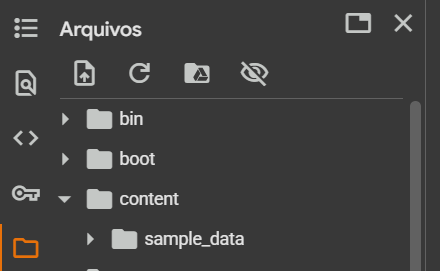


In [ ]:
### IMPORTANDO ARQUIVOS QUE SERÃO USADOS NO TESTE ###

!wget https://raw.githubusercontent.com/KaelDucatti/pyspark_test_data/main/products.json -O products.json
!wget https://raw.githubusercontent.com/KaelDucatti/pyspark_test_data/main/sales.csv -O sales.csv
!wget https://raw.githubusercontent.com/KaelDucatti/pyspark_test_data/main/users.csv -O users.csv

path_products = "/content/products.json"
path_sales = "/content/sales.csv"
path_users = "/content/users.csv"

In [2]:
### IMPORTANDO BIBLIOTECAS NECESSÁRIAS ###

from pyspark.sql import SparkSession
from pyspark.sql.functions import *

In [3]:
### INSTANCIANDO SPARK ###

spark = SparkSession.builder.appName('test-spark').getOrCreate()

---

# Seu teste começa aqui 🍀 Boa sorte!

In [4]:
users_df = spark.read.csv(path_users, header=True, inferSchema=True)
sales_df = spark.read.csv(path_sales, header=True, inferSchema=True)
products_df = spark.read.json(path_products)

In [15]:
sales_df.show()
users_df.show()
products_df.show()

+-------+----------+----------+---------+----+
|sale_id|      date|product_id|client_id|qtde|
+-------+----------+----------+---------+----+
|      1|13/06/2022|        30|      223|   2|
|      2|16/11/2022|        23|      175|   2|
|      3|18/08/2022|        29|      184|   2|
|      4|13/03/2022|        31|      194|   1|
|      5|14/12/2022|        13|      221|   2|
|      6|18/01/2022|        26|      206|   1|
|      7|12/10/2022|        28|      123|   2|
|      8|15/06/2022|        39|      269|   2|
|      9|15/02/2022|        36|      179|   3|
|     10|06/12/2022|        41|      148|   1|
|     11|30/04/2022|        34|       81|   1|
|     12|05/04/2022|        48|       98|   3|
|     13|24/03/2022|        24|      180|   1|
|     14|20/11/2022|         1|       97|   3|
|     15|23/03/2022|        12|      270|   2|
|     16|28/11/2022|        25|      128|   1|
|     17|24/04/2022|        49|      165|   2|
|     18|21/10/2022|        28|       18|   3|
|     19|01/1

In [24]:
sales_enriched_df = sales_df.join(products_df, "product_id", "inner") \
    .withColumn("price_clean", regexp_replace(col("price"), r"[\$,]", "").cast("double")) \
    .withColumn("valor_final", col("qtde") * col("price_clean")) \
    .withColumn("date", to_date(col("date"), "dd/MM/yyyy")) \
    .drop("price_clean")

In [17]:
#Questao 1
df_q1 = sales_enriched_df.select('product','valor_final')
df_q1.show()

+------------------+-----------+
|           product|valor_final|
+------------------+-----------+
|     Blusa Cropped|      214.5|
|Camiseta Estampada|     218.38|
|     Óculos de Sol|     244.54|
|        Bolsa Tote|     105.96|
|     Camisa Social|     161.52|
|Conjunto de Pijama|      85.49|
|     Camiseta Polo|     224.04|
|        Macaquinho|     191.32|
|     Chapéu Fedora|     301.77|
|    Blusa de Renda|       98.9|
|     Camisa Xadrez|      102.7|
|         Sapatênis|     251.76|
|        Sapatilhas|     123.33|
|       Camisa Polo|      259.5|
| Casaco de Inverno|     235.76|
|Suéter de Cashmere|      82.64|
|Calça Cintura Alta|      218.6|
|     Camiseta Polo|     336.06|
|     Jaqueta Jeans|     116.02|
|  Vestido Camisola|       95.6|
+------------------+-----------+
only showing top 20 rows


In [19]:
#Questao 2
df_q2 = sales_enriched_df.groupBy('client_id')\
.agg(sum('valor_final').alias('total_spent'))
df_q2.show()

+---------+------------------+
|client_id|       total_spent|
+---------+------------------+
|      148|            307.88|
|      243|            280.28|
|       31|            1755.6|
|      137| 624.8199999999999|
|      251|            837.55|
|       85|            688.92|
|       65|            124.43|
|       53|1751.6699999999998|
|      255| 791.3599999999999|
|      133|           1107.99|
|      296| 787.0799999999999|
|       78|           1260.94|
|      155|            974.77|
|      108|            538.87|
|      211|            708.44|
|       34|             851.9|
|      193|            374.04|
|      126| 884.0600000000001|
|      101|1176.8899999999999|
|      115|            201.18|
+---------+------------------+
only showing top 20 rows


In [20]:
#Questao 3
df_q3 = df_q2.join(users_df, 'client_id', 'inner') \
.select(users_df.name, users_df.email, 'total_spent')\
.orderBy(desc('total_spent')) \
.limit(5)
df_q3.show()



+-----------------+--------------------+------------------+
|             name|               email|       total_spent|
+-----------------+--------------------+------------------+
|Randa Friedenbach|rfriedenbach3m@pa...|           2240.51|
|  Giuditta Blease|gblease6s@friendf...|           1902.85|
|     Cher Higford| chigfordn@issuu.com|           1843.35|
|    Keen Juggings|kjuggings5j@phoca.cz|1795.8600000000001|
|    Alfie Pattlel|apattlelu@discuz.net|            1755.6|
+-----------------+--------------------+------------------+



In [27]:
#Questao 4
max_date_row = sales_enriched_df.agg(max("date").alias("max_date")).collect()[0]
max_date = max_date_row["max_date"]

df_q4 = sales_enriched_df.filter(col("date") >= add_months(lit(max_date), -6)) \
    .groupBy("product") \
    .agg(sum("qtde").alias("total_quantity")) \
    .orderBy(desc("total_quantity")) \
    .limit(5)

df_q4.show()

+--------------------+--------------+
|             product|total_quantity|
+--------------------+--------------+
|          Macaquinho|            39|
|Blusa de Manga Longa|            34|
|      Blusa de Malha|            29|
|   Casaco de Inverno|            29|
|      Bolsa de Couro|            27|
+--------------------+--------------+



In [30]:
#Questao 5
stats = df_q2.agg(
    mean("total_spent").alias("media_faturamento"),
    stddev("total_spent").alias("desvio_padrao")
).collect()[0]

media_fat = stats["media_faturamento"]
desvio_pad = stats["desvio_padrao"]

print(f"Média de Faturamento: {media_fat}")
print(f"Desvio Padrão: {desvio_pad}")

Média de Faturamento: 707.2573539518903
Desvio Padrão: 414.3416116528876


In [31]:
#Questao 6
df_q6 = df_q2.withColumn(
    'customer_category',
    when(col('total_spent') > media_fat, 'platinum')
    .when(col('total_spent') > (media_fat - desvio_pad), 'gold')
    .otherwise('silver')
)

df_q6.show()

+---------+------------------+-----------------+
|client_id|       total_spent|customer_category|
+---------+------------------+-----------------+
|      148|            307.88|             gold|
|      243|            280.28|           silver|
|       31|            1755.6|         platinum|
|      137| 624.8199999999999|             gold|
|      251|            837.55|         platinum|
|       85|            688.92|             gold|
|       65|            124.43|           silver|
|       53|1751.6699999999998|         platinum|
|      255| 791.3599999999999|         platinum|
|      133|           1107.99|         platinum|
|      296| 787.0799999999999|         platinum|
|       78|           1260.94|         platinum|
|      155|            974.77|         platinum|
|      108|            538.87|             gold|
|      211|            708.44|         platinum|
|       34|             851.9|         platinum|
|      193|            374.04|             gold|
|      126| 884.0600

In [34]:
#Questao 7

from pyspark.sql.window import Window

category_sales_df = sales_enriched_df.join(df_q6, "client_id", "inner") \
    .groupBy("customer_category", 'product') \
    .agg(sum("qtde").alias("total_consumed"))

window_spec = Window.partitionBy('customer_category').orderBy(desc('total_consumed'))

top_3_products_by_category = category_sales_df\
.withColumn('rank', row_number().over(window_spec))\
.filter(col('rank') <= 3)\
.drop('rank')

top_3_products_by_category.write\
.mode('overwrite')\
.parquet('top_3_produtos_por_categoria.parquet')



+-----------------+--------------------+--------------+
|customer_category|             product|total_consumed|
+-----------------+--------------------+--------------+
|             gold|   Casaco de Inverno|            26|
|             gold|      Cinto de Couro|            26|
|             gold|       Camisa Xadrez|            23|
|         platinum|Blusa de Manga Longa|            57|
|         platinum|     Mochila de Lona|            52|
|         platinum|  Calça Cintura Alta|            45|
|           silver|          Macaquinho|             7|
|           silver|Sapatos de Salto ...|             6|
|           silver|        Vestido Midi|             5|
+-----------------+--------------------+--------------+



In [35]:
df_parquet = spark.read.parquet('top_3_produtos_por_categoria.parquet')
df_parquet.show()

+-----------------+--------------------+--------------+
|customer_category|             product|total_consumed|
+-----------------+--------------------+--------------+
|             gold|   Casaco de Inverno|            26|
|             gold|      Cinto de Couro|            26|
|             gold|       Camisa Xadrez|            23|
|         platinum|Blusa de Manga Longa|            57|
|         platinum|     Mochila de Lona|            52|
|         platinum|  Calça Cintura Alta|            45|
|           silver|          Macaquinho|             7|
|           silver|Sapatos de Salto ...|             6|
|           silver|        Vestido Midi|             5|
+-----------------+--------------------+--------------+

